In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/nyc-taxi-trip-duration/train.zip
/kaggle/input/competitions/nyc-taxi-trip-duration/test.zip
/kaggle/input/competitions/nyc-taxi-trip-duration/sample_submission.zip


In [2]:
df = pd.read_csv('/kaggle/input/competitions/nyc-taxi-trip-duration/train.zip')

In [3]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df.shape

(1458644, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [6]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [7]:
df[['pickup_latitude', 'pickup_longitude']].describe()

,pickup_latitude,pickup_longitude
count,1.458644e+06,1.458644e+06
mean,4.075092e+01,-7.397349e+01
std,3.288119e-02,7.090186e-02
min,3.435970e+01,-1.219333e+02
25%,4.073735e+01,-7.399187e+01
50%,4.075410e+01,-7.398174e+01
75%,4.076836e+01,-7.396733e+01
max,5.188108e+01,-6.133553e+01


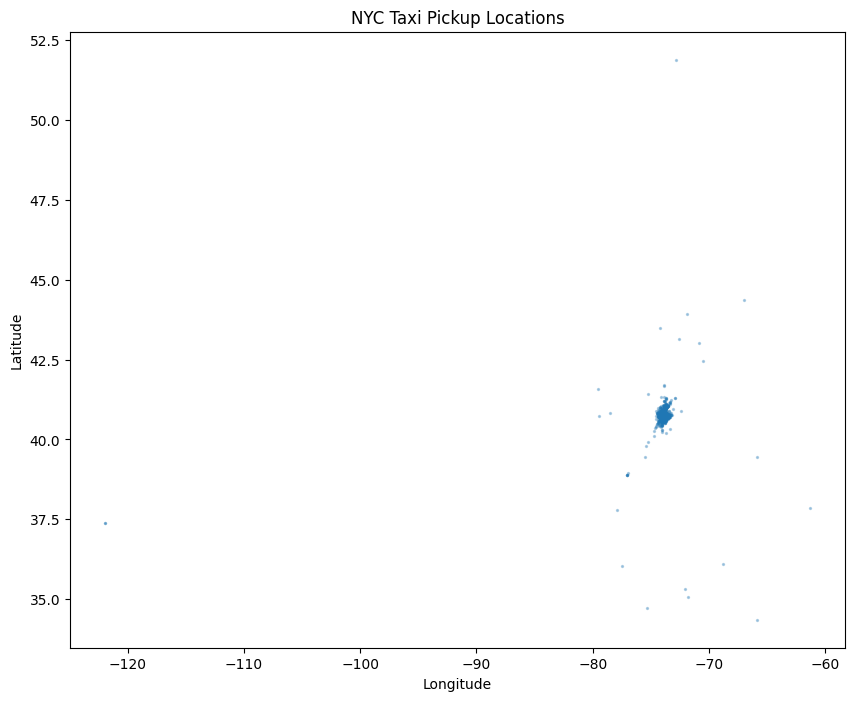

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(
    df['pickup_longitude'],
    df['pickup_latitude'],
    s=2,
    alpha=0.3
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('NYC Taxi Pickup Locations')
plt.show()

In [9]:
sample = df.sample(10000, random_state=42)

coords_sample = np.radians(
    sample[['pickup_latitude', 'pickup_longitude']].to_numpy()
)

In [10]:
from sklearn.cluster import DBSCAN

In [11]:
dbscan = DBSCAN(
    eps=0.001,
    min_samples=10,
    metric='haversine'
)

In [12]:
from sklearn.neighbors import NearestNeighbors

In [13]:
neighbors = NearestNeighbors(
    n_neighbors=11,
    metric='haversine'
)

neighbors.fit(coords_sample)

distances, indices = neighbors.kneighbors(coords_sample)

k_distances = np.sort(distances[:, 10])

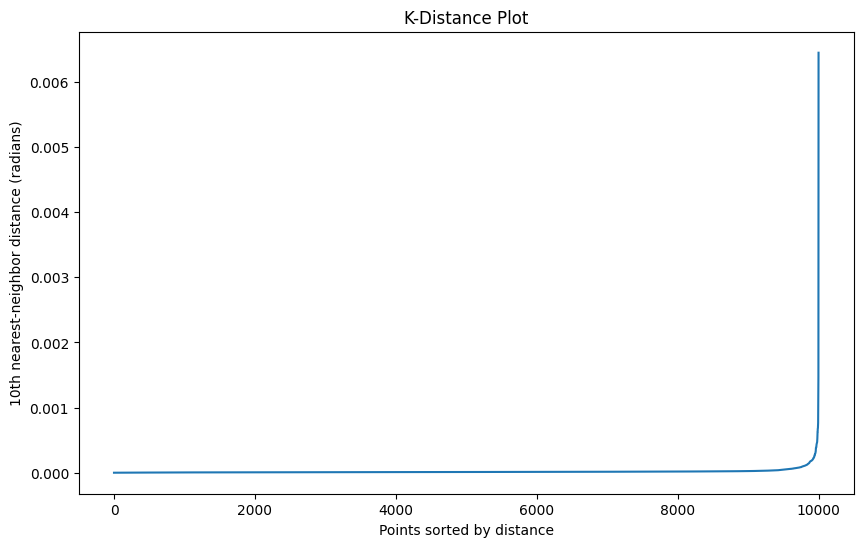

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('10th nearest-neighbor distance (radians)')
plt.title('K-Distance Plot')
plt.show()

In [15]:
eps = 0.0001

In [16]:
earth_radius_km = 6371

eps_km = 0.0001 * earth_radius_km

print(eps_km)

0.6371


In [17]:
sample = df.sample(50000, random_state=42)

coords_sample = np.radians(
    sample[['pickup_latitude', 'pickup_longitude']].to_numpy()
)

dbscan = DBSCAN(
    eps=0.0001,
    min_samples=10,
    metric='haversine'
)

labels = dbscan.fit_predict(coords_sample)

In [18]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters: 9
Number of noise points: 215


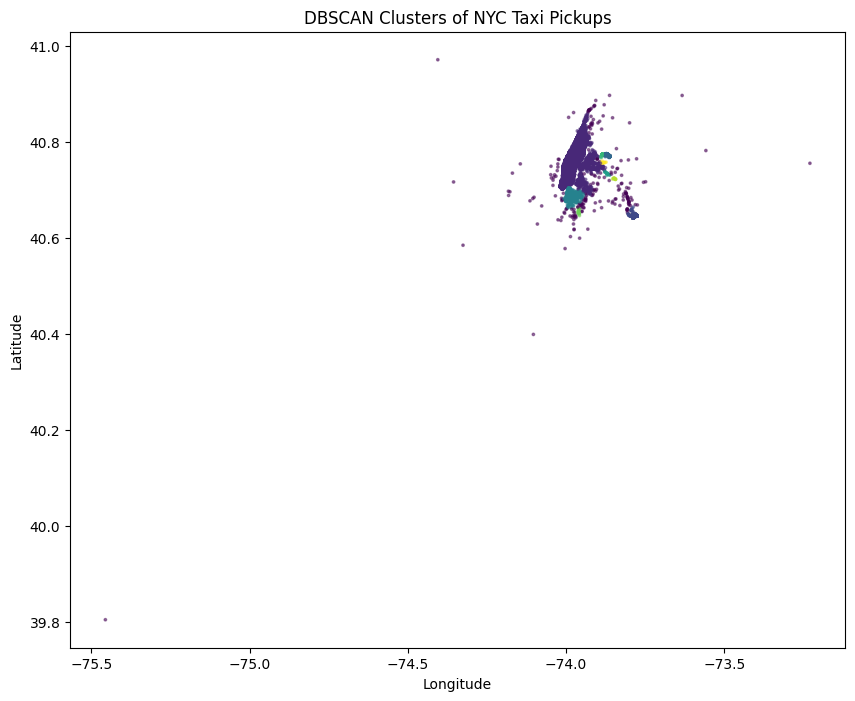

In [19]:
plt.figure(figsize=(10, 8))

plt.scatter(
    sample['pickup_longitude'],
    sample['pickup_latitude'],
    c=labels,
    s=3,
    alpha=0.5
)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('DBSCAN Clusters of NYC Taxi Pickups')
plt.show()

In [20]:
pd.Series(labels).value_counts().sort_index()

-1      215
 0    46807
 1     1078
 2     1295
 3      520
 4       14
 5       37
 6       14
 7       10
 8       10
Name: count, dtype: int64

In [21]:
for eps in [0.00005, 0.000075, 0.0001, 0.00015, 0.0002]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10,
        metric='haversine'
    )
    
    labels = dbscan.fit_predict(coords_sample)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    print(
        f"eps={eps}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )

eps=5e-05: clusters=15, noise=557
eps=7.5e-05: clusters=10, noise=341
eps=0.0001: clusters=9, noise=215
eps=0.00015: clusters=4, noise=101
eps=0.0002: clusters=2, noise=82


In [22]:
for eps in [0.00005, 0.000075, 0.0001]:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10,
        metric='haversine'
    )
    
    labels = dbscan.fit_predict(coords_sample)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    
    print(f"\nEPS = {eps}")
    print(cluster_sizes)


EPS = 5e-05
-1       557
 0     45911
 1      1058
 2       260
 3      1295
 4        33
 5       136
 6        28
 7        83
 8       428
 9        86
 10       49
 11       20
 12       10
 13       34
 14       12
Name: count, dtype: int64

EPS = 7.5e-05
-1      341
 0    45953
 1     1064
 2      272
 3     1295
 4      492
 5      504
 6       12
 7       34
 8       23
 9       10
Name: count, dtype: int64

EPS = 0.0001
-1      215
 0    46807
 1     1078
 2     1295
 3      520
 4       14
 5       37
 6       14
 7       10
 8       10
Name: count, dtype: int64


In [23]:
for min_samples in [5, 10, 20, 30, 50]:
    dbscan = DBSCAN(
        eps=0.0001,
        min_samples=min_samples,
        metric='haversine'
    )
    
    labels = dbscan.fit_predict(coords_sample)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    
    print(
        f"min_samples={min_samples}: "
        f"clusters={n_clusters}, "
        f"noise={n_noise}"
    )

min_samples=5: clusters=8, noise=121
min_samples=10: clusters=9, noise=215
min_samples=20: clusters=7, noise=358
min_samples=30: clusters=7, noise=441
min_samples=50: clusters=7, noise=664


In [24]:
cluster_centers = (
    sample.assign(cluster=labels)
    .query("cluster != -1")
    .groupby("cluster")[["pickup_latitude", "pickup_longitude"]]
    .mean()
    .reset_index()
)

cluster_centers

,cluster,pickup_latitude,pickup_longitude
0,0,40.753874,-73.981719
1,1,40.645314,-73.784024
2,2,40.715917,-73.955436
3,3,40.771880,-73.868345
4,4,40.744043,-73.921379
5,5,40.687841,-73.986255
6,6,40.758995,-73.932102


In [25]:
cluster_centers["pickup_latitude"] = cluster_centers["pickup_latitude"].round(5)
cluster_centers["pickup_longitude"] = cluster_centers["pickup_longitude"].round(5)

cluster_centers

,cluster,pickup_latitude,pickup_longitude
0,0,40.75387,-73.98172
1,1,40.64531,-73.78402
2,2,40.71592,-73.95544
3,3,40.77188,-73.86834
4,4,40.74404,-73.92138
5,5,40.68784,-73.98626
6,6,40.75899,-73.93210


DBSCAN identified a dominant pickup cluster centered around Midtown Manhattan, reflecting the high concentration of taxi activity in central Manhattan. Additional smaller clusters were detected around JFK Airport, Brooklyn, and LaGuardia Airport, while isolated observations were classified as noise.

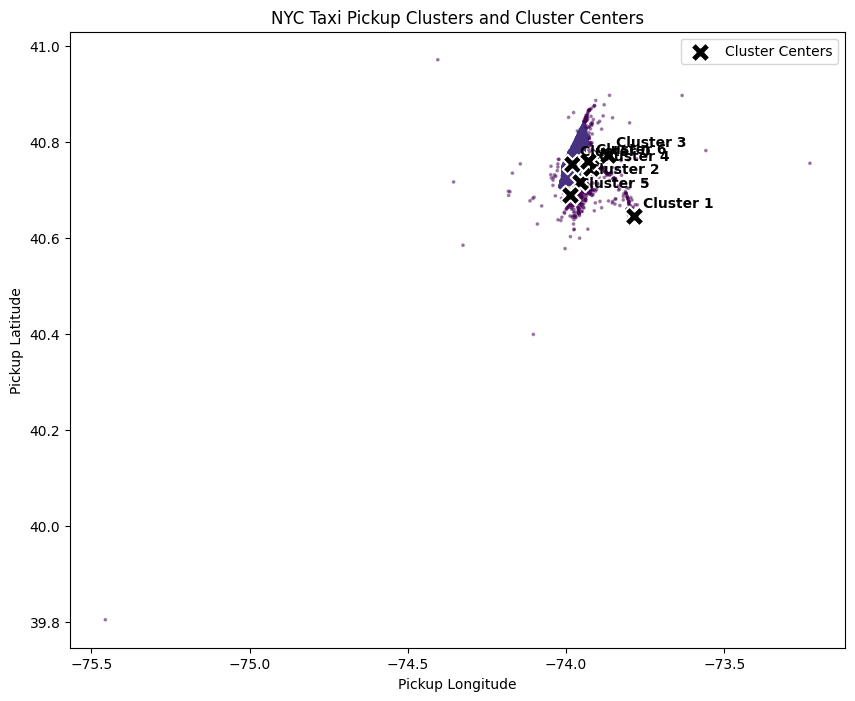

In [26]:

plt.figure(figsize=(10, 8))

# Original pickup coordinates
plt.scatter(
    sample['pickup_longitude'],
    sample['pickup_latitude'],
    c=labels,
    s=3,
    alpha=0.4
)

# Cluster centers
plt.scatter(
    cluster_centers['pickup_longitude'],
    cluster_centers['pickup_latitude'],
    marker='X',
    s=200,
    c='black',
    edgecolors='white',
    linewidths=1.5,
    label='Cluster Centers'
)

# Add cluster labels
for _, row in cluster_centers.iterrows():
    plt.annotate(
        f"Cluster {int(row['cluster'])}",
        (row['pickup_longitude'], row['pickup_latitude']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=10,
        fontweight='bold'
    )

plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.title('NYC Taxi Pickup Clusters and Cluster Centers')
plt.legend()
plt.show()